# Mass-action kinetics, single binding 

This notebook explores several models of AMPK activation. 

Nathaniel Linden (UCSD MAE) - Mar  2023

In [1]:
import sunode
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym
import sys
from sympy import init_printing
init_printing()
sys.path.append('../odes/')
import ampk_MA_single_mech as model
from get_left_nullspace_vecs_invariants import get_left_nullspace_vecs_invariants as left_ns
%matplotlib inline

WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# # Code for replacing flux terms with iterable indexes
# for i in reversed(range(27)):
#     #read input file
#     fin = open("../odes/tmp.txt", "rt")
#     #read file contents to string
#     data = fin.read()
#     #replace all occurrences of the required string
#     data = data.replace('J'+str(i), 'fluxes[{i}]'.format(i=i-1))
#     #close the input file
#     fin.close()
#     #open the input file in write mode
#     fin = open("../odes/tmp.txt", "wt")
#     #overrite the input file with the resulting data
#     fin.write(data)
#     #close the file
#     fin.close()

We will start with the relevant initial conditions and parameters from Coccimiglio et al.
Parameter values are taken from Sup Table D col "pre-calibration value," thus they are from Xiao et al. Nature 2011.
Initial conditions are taken from Sup Table 

Parameters not included in that model are assigned arbitrarily. 

**Note that this simulation just tests the machinery of the model and simulation!**

In [3]:
# First we want to check that the model obeys proper conservation of mass
# use our function for this
rhs, sym_fluxes = model.ampk_MA_single_mech_RHS_sympyFluxVars()
stoich, left_ns_vecs, invars = left_ns(rhs, sym_fluxes)
for idx, invariant in zip(range(len(invars)), invars):
    print('The {} invariant is:'.format(idx))
    sym.pprint(invariant, use_unicode=True)
    print('\n')

The 0 invariant is:
[CaMKK + CaMKKADPAMPK + CaMKKAMPAMPK + CaMKKAMPK + CaMKKATPAMPK]


The 1 invariant is:
[LKB₁ + LKB1ADPAMPK + LKB1AMPAMPK]


The 2 invariant is:
[-ADP - AMP + AMPK - ATP + CaMKKAMPK + PPpAMPK + pAMPK]


The 3 invariant is:
[ADP + AMP - AMPK + ATP - CaMKKAMPK + PP + PPATPpAMPK - pAMPK]


The 4 invariant is:
[ADPAMPK + ADPpAMPK + AMPAMPK + AMPK + AMPKARAMPpAMPK + AMPpAMPK + ATPAMPK + A
TPpAMPK - CaMKK - LKB₁ - PP + pAMPK]


The 5 invariant is:
[ADPAMPK + ADPpAMPK + AMPAMPK + AMPK - AMPKAR + AMPpAMPK + ATPAMPK + ATPpAMPK 
- CaMKK - LKB₁ - PP + PP₁ + pAMPK - pAMPKAR]


The 6 invariant is:
[-ADPAMPK - ADPpAMPK - AMPAMPK - AMPK + AMPKAR - AMPpAMPK - ATPAMPK - ATPpAMPK
 + CaMKK + LKB₁ + PP + PP1pAMPKAR - pAMPK + pAMPKAR]




In [8]:
# 2 + 3
print('Invariant {i} + {j}:'.format(i=2, j=3))
sym.pprint(invars[2]+invars[3], use_unicode=True)
print('\n')

# 6 + 4
print('Invariant {i} + {j}:'.format(i=4, j=6))
sym.pprint(invars[4]+invars[6], use_unicode=True)
print('\n')

# 5 + 6
print('Invariant {i} + {j}:'.format(i=5, j=6))
sym.pprint(invars[5]+invars[6], use_unicode=True)
print('\n')

# 3 + 4 + 1 + 0
print('Invariant {i} + {j} + {k} + {l}:'.format(i=3, j=4, k=1, l=0))
sym.pprint(invars[3]+invars[4]+invars[1]+invars[0], use_unicode=True)

# 0 + 1 + 2 + 3 + 4
print('Invariant {i} + {j} + {k} + {l} + {m}:'.format(i=0, j=1, k=2, l=3, m=4))
sym.pprint(invars[0]+invars[1]+invars[2]+invars[3]+invars[4], use_unicode=True)

Invariant 2 + 3:
[PP + PPATPpAMPK + PPpAMPK]


Invariant 4 + 6:
[AMPKAR + AMPKARAMPpAMPK + PP1pAMPKAR + pAMPKAR]


Invariant 5 + 6:
[PP₁ + PP1pAMPKAR]


Invariant 3 + 4 + 1 + 0:
[ADP + ADPAMPK + ADPpAMPK + AMP + AMPAMPK + AMPKARAMPpAMPK + AMPpAMPK + ATP + 
ATPAMPK + ATPpAMPK + CaMKKADPAMPK + CaMKKAMPAMPK + CaMKKATPAMPK + LKB1ADPAMPK 
+ LKB1AMPAMPK + PPATPpAMPK]
Invariant 0 + 1 + 2 + 3 + 4:
[ADPAMPK + ADPpAMPK + AMPAMPK + AMPK + AMPKARAMPpAMPK + AMPpAMPK + ATPAMPK + A
TPpAMPK + CaMKKADPAMPK + CaMKKAMPAMPK + CaMKKAMPK + CaMKKATPAMPK + LKB1ADPAMPK
 + LKB1AMPAMPK + PPATPpAMPK + PPpAMPK + pAMPK]


In [30]:
# load the necessary dictionaries
params = model.ampk_MA_single_mech_get_params()
states = model.ampk_MA_single_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model.ampk_MA_single_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
# free adenine nucleotides
y0['AMP'] = 2e-5   # 'AMP' mM
y0['ATP'] = 1.3e-1 # 'ADP mM
y0['ADP'] = 8.2   # 'ATP mM
# # free AMPK
y0['AMPK'] = 6   # 'AMPK mM
y0['pAMPK'] = 0   # 'pAMPK mM
# # single AXP-AMPK complexes
y0['AMP_AMPK'] = 0  # 'AMP_AMPK mM
y0['ADP_AMPK'] = 0   # 'ADP_AMPK mM
y0['ATP_AMPK'] = 0   # 'ATP_AMPK mM
# # single AXP-pAMPK complexes
y0['AMP_pAMPK'] = 0   # 'AMP_pAMPK mM
y0['ADP_pAMPK'] = 0   # 'ADP_pAMPK mM
y0['ATP_pAMPK'] = 0   # 'ATP_pAMPK mM
# # double AXP-AMPK complexes
# # CaMKK complexes
y0['CaMKK'] = 10.0   # 'CaMKK_AMPK mM
y0['CaMKK_AMPK'] = 0   # 'CaMKK_AMPK mM
y0['CaMKK_AMP_AMPK'] = 0   # 'CaMKK_AMP_AMPK mM
y0['CaMKK_ADP_AMPK'] = 0   # 'CaMKK_ADP_AMPK mM
y0['CaMKK_ATP_AMPK'] = 0   # 'CaMKK_ATP_AMPK mM
y0['LKB1'] = 10.0   # 'CaMKK_AMPK mM
y0['LKB1_AMP_AMPK'] = 0   # 'LKB1_AMP_AMPK mM
y0['LKB1_ADP_AMPK'] = 0   # 'LKB1_ADP_AMPK mM
# # AMPK phosphatase complexes
y0['PP'] = 5.0   # 'CaMKK_AMPK mM
y0['PP_pAMPK'] = 0   # 'PP_pAMPK mM
y0['PP_ATP_pAMPK'] = 0   # 'PP_ATP_pAMPK mM
# # free AMPKAR
y0['AMPKAR'] = 3.0   # 'AMPKAR mM
y0['pAMPKAR'] = 0   # pAMPKAR
# # AMPKAR-pAMPK complexes
y0['AMPKAR_AMP_pAMPK'] = 0   # 'AMPKAR_AMP_pAMPK' mM
# # AMPKAR phosphatase complexes
y0['PP1'] = 5.0   # 'CaMKK_AMPK mM
y0['PP1_pAMPKAR'] = 0   # 'PP1_pAMPKAR mM

 # evaluate the solution at these times
tvals = np.linspace(0, 300, 500)

 # set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kOnAMP': 1, # 1/(mM s) - from Coccimiglio 
    'kOffAMP': 2.5e-3, # 1/s - from Coccimiglio 
    'kOnADP': 1 , # 1/(mM s) - from Coccimiglio
    'kOffADP': 1.5e-3, # 1/s - from Coccimiglio
    'kOnATP': 1, # 1/(mM s) - from Coccimiglio 
    'kOffATP': 1.8e-2, # 1/s - from Coccimiglio
    'kOnCaMKK': 1, # TODO - random value!
    'kOffCaMKK': 1e-2, # TODO - random value!
    'kPhosCaMKK': 6.7e-2, # from Coccimiglio, but incorrect parameters 
    'kOnLKB1': 1, # TODO - random value!
    'kOffLKB1': 1e-2, # TODO - random value!
    'kPhosLKB1': 6.7e-2, # from Coccimiglio, but incorrect parameters 
    'kOnPP': 1, # TODO - random value! 
    'kOffPP': 1e-2, # TODO - random value! 
    'kDephosPP': 1.1e-2, # from Coccimiglio, but incorrect parameters 
    'kOnAMPK': 1, # TODO - random value!
    'kOffAMPK': 1e-2, # TODO - random value!
    'kPhosAMPK': 5e-1, # TODO - random value!
    'kOnPP1': 1, # TODO - random value!
    'kOffPP1': 1e-2, # TODO - random value!
    'kDephosPP1': 5e-3, # TODO - random value!
    'kGly': 0.02, # TODO - random value!
    'kHydro':0.05, # TODO - random value!
    'kForAK':4e-6, # TODO - random value!
    'kRevAK':1e-7, # TODO - random value!
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})

sens0 = np.zeros((nparams, nstates))
yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout, sens0=sens0)

Text(0.5, 1.0, 'Adenine nucleotide ratios')

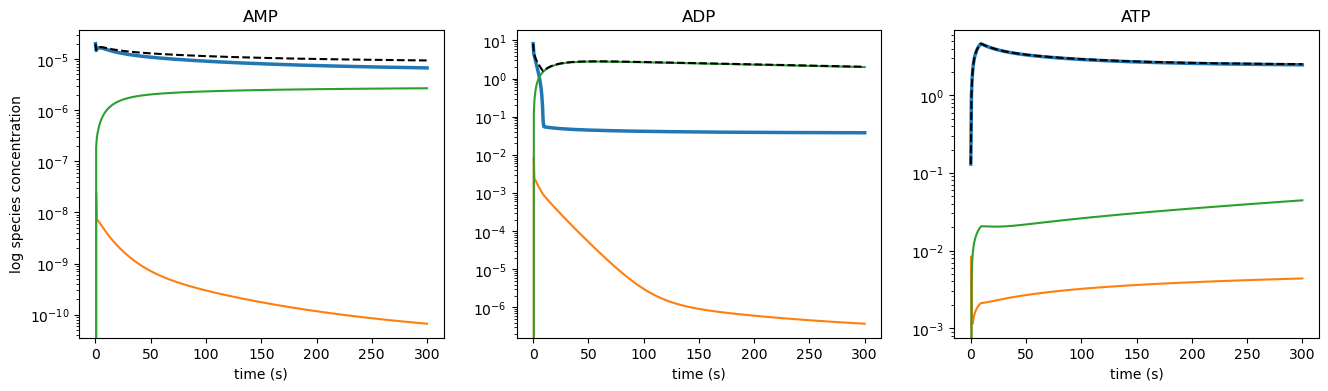

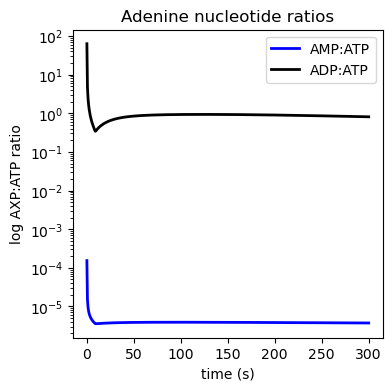

In [31]:
# Metabolism plots
fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
# AMP
# plot [AMP] with thicker line
ax0[0].plot(tvals, yout.view(problem.state_dtype)['AMP'], linewidth=2.5)
AMPtot = yout.view(problem.state_dtype)['AMP']
# everything else
states_to_plot = ['AMP_AMPK', 'AMP_pAMPK']
for state in states_to_plot:
    ax0[0].plot(tvals, yout.view(problem.state_dtype)[state])
    AMPtot += yout.view(problem.state_dtype)[state]
# all AMP-x complexes
ax0[0].plot(tvals, AMPtot, 'k--')
# formatting
ax0[0].set_yscale('log')
ax0[0].set_ylabel('log species concentration')
ax0[0].set_xlabel('time (s)')
ax0[0].set_title('AMP')
# ADP
# plot [ADP] with thicker line
ax0[1].plot(tvals, yout.view(problem.state_dtype)['ADP'], linewidth=2.5)
ADPtot = yout.view(problem.state_dtype)['ADP']
# everything else
states_to_plot = ['ADP_AMPK', 'ADP_pAMPK']
for state in states_to_plot:
    ax0[1].plot(tvals, yout.view(problem.state_dtype)[state])
    ADPtot += yout.view(problem.state_dtype)[state]
# all ADP-x complexes
ax0[1].plot(tvals, ADPtot, 'k--')
# formatting
ax0[1].set_yscale('log')
ax0[1].set_xlabel('time (s)')
ax0[1].set_title('ADP')
# ATP
# plot [ADP] with thicker line
ax0[2].plot(tvals, yout.view(problem.state_dtype)['ATP'], linewidth=2.5)
ATPtot = yout.view(problem.state_dtype)['ATP']
# everything else
states_to_plot = ['ATP_AMPK', 'ATP_pAMPK']
for state in states_to_plot:
    ax0[2].plot(tvals, yout.view(problem.state_dtype)[state])
    ATPtot += yout.view(problem.state_dtype)[state]
# all ATP-x complexes
ax0[2].plot(tvals, ATPtot, 'k--')
# formatting
ax0[2].set_yscale('log')
ax0[2].set_xlabel('time (s)')
ax0[2].set_title('ATP')

fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
AMP_ATP_ratio = yout.view(problem.state_dtype)['AMP'] / yout.view(problem.state_dtype)['ATP']
ADP_ATP_ratio = yout.view(problem.state_dtype)['ADP'] / yout.view(problem.state_dtype)['ATP']
ax1.plot(tvals, AMP_ATP_ratio, 'b', linewidth=2)
ax1.plot(tvals, ADP_ATP_ratio, 'k', linewidth=2)
ax1.set_yscale('log')
ax1.set_ylabel('log AXP:ATP ratio')
ax1.set_xlabel('time (s)')
ax1.legend(('AMP:ATP', 'ADP:ATP'))
ax1.set_title('Adenine nucleotide ratios')

Text(0.5, 1.0, 'AMPK')

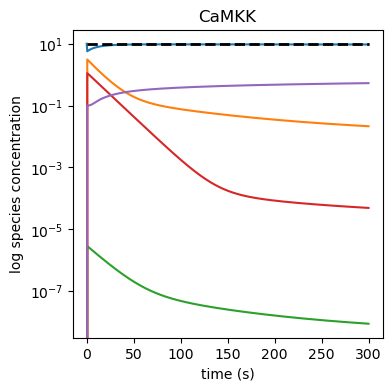

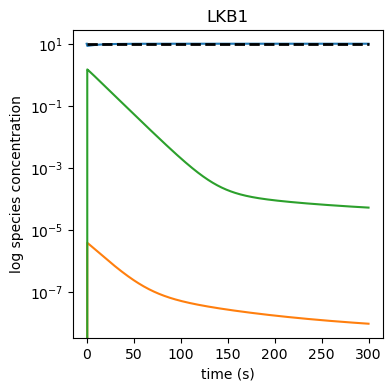

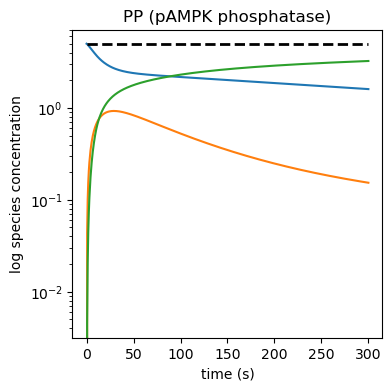

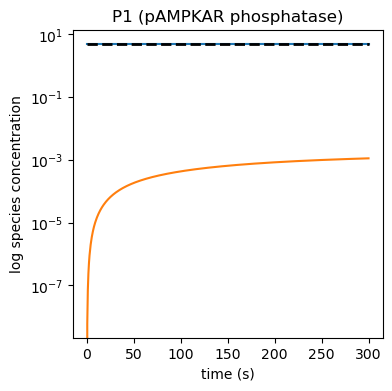

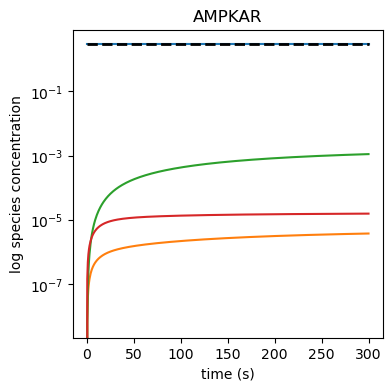

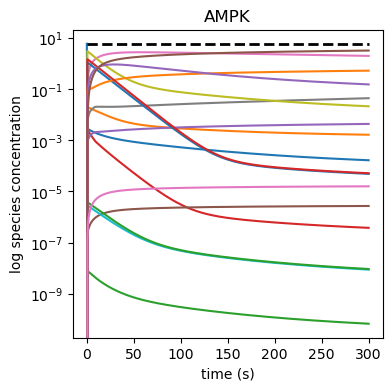

In [32]:
# Conserved quantities
# CaMKK
states_to_plot = ['CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 
                  'CaMKK_ATP_AMPK']
fig0, ax0 = plt.subplots(1,1, figsize=(4,4))
CaMKKtot = np.zeros(yout.view(problem.state_dtype)['CaMKK'].shape)
for state in states_to_plot:
    CaMKKtot += yout.view(problem.state_dtype)[state]
    ax0.plot(tvals, yout.view(problem.state_dtype)[state])
ax0.plot(tvals, CaMKKtot, 'k--', linewidth=2)
ax0.set_yscale('log')
ax0.set_ylabel('log species concentration')
ax0.set_xlabel('time (s)')
ax0.set_title('CaMKK')

# LKB1
states_to_plot = ['LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK']
fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
LKB1tot = np.zeros(yout.view(problem.state_dtype)['LKB1'].shape)
for state in states_to_plot:
    LKB1tot += yout.view(problem.state_dtype)[state]
    ax1.plot(tvals, yout.view(problem.state_dtype)[state])
ax1.plot(tvals, LKB1tot, 'k--', linewidth=2)
ax1.set_yscale('log')
ax1.set_ylabel('log species concentration')
ax1.set_xlabel('time (s)')
ax1.set_title('LKB1')

# PP
states_to_plot = ['PP', 'PP_pAMPK', 'PP_ATP_pAMPK']
fig2, ax2 = plt.subplots(1,1, figsize=(4,4))
PPtot = np.zeros(yout.view(problem.state_dtype)['PP'].shape)
for state in states_to_plot:
    PPtot += yout.view(problem.state_dtype)[state]
    ax2.plot(tvals, yout.view(problem.state_dtype)[state])
ax2.plot(tvals, PPtot, 'k--', linewidth=2)
ax2.set_yscale('log')
ax2.set_ylabel('log species concentration')
ax2.set_xlabel('time (s)')
ax2.set_title('PP (pAMPK phosphatase)')

# PP1
states_to_plot = ['PP1','PP1_pAMPKAR']
fig3, ax3 = plt.subplots(1,1, figsize=(4,4))
PP1tot = np.zeros(yout.view(problem.state_dtype)['PP1'].shape)
for state in states_to_plot:
    PP1tot += yout.view(problem.state_dtype)[state]
    ax3.plot(tvals, yout.view(problem.state_dtype)[state])
ax3.plot(tvals, PP1tot, 'k--', linewidth=2)
ax3.set_yscale('log')
ax3.set_ylabel('log species concentration')
ax3.set_xlabel('time (s)')
ax3.set_title('P1 (pAMPKAR phosphatase)')

# AMPKAR
states_to_plot = ['AMPKAR', 'pAMPKAR', 'PP1_pAMPKAR', 'AMPKAR_AMP_pAMPK']
fig4, ax4 = plt.subplots(1,1, figsize=(4,4))
AMPKARtot = np.zeros(yout.view(problem.state_dtype)['AMPKAR'].shape)
for state in states_to_plot:
    AMPKARtot += yout.view(problem.state_dtype)[state]
    ax4.plot(tvals, yout.view(problem.state_dtype)[state])
ax4.plot(tvals, AMPKARtot, 'k--', linewidth=2)
ax4.set_yscale('log')
ax4.set_ylabel('log species concentration')
ax4.set_xlabel('time (s)')
ax4.set_title('AMPKAR')

# AMPK
states_to_plot = ['AMPK', 'pAMPK', # uncomplexed
                  'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', # single complex
                  'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK',
                  'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', # CaMKK complexes
                  'CaMKK_ATP_AMPK',
                  'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', # LKB1 complexes
                  'PP_pAMPK', 'PP_ATP_pAMPK', # PP complexes
                  'AMPKAR_AMP_pAMPK', # AMPKAR complexes
                  ]
fig5, ax5 = plt.subplots(1,1, figsize=(4,4))
AMPKtot = np.zeros(yout.view(problem.state_dtype)['AMPK'].shape)
for state in states_to_plot:
    AMPKtot += yout.view(problem.state_dtype)[state]
    ax5.plot(tvals, yout.view(problem.state_dtype)[state])
ax5.plot(tvals, AMPKtot, 'k--', linewidth=2)
ax5.set_yscale('log')
ax5.set_ylabel('log species concentration')
ax5.set_xlabel('time (s)')
ax5.set_title('AMPK')